# Paper-Tiger 🐯
### A backtest that "beats the market" — does it, really?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats the market?: Not supported](https://img.shields.io/badge/Beats_the_market%3F-Not_supported-8b949e?style=flat-square)

A vendor sells a dual-momentum strategy with a shiny backtest: ride the strongest stock market, flee to bonds before crashes, beat buy-and-hold. We rebuild it faithfully on real ETFs and check the headline against the benchmarks a sceptic would actually use. The book makes money — but the statistics turn out to belong to the *assets it holds*, not to the switching rule, and the reason it sells is a paper tiger.

> 📓 **This is the plain-language layer.** The statistics, the spanning test and the portfolio maths live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (paper_tiger/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from paper_tiger import data, strategy as st

prices, tbill = data.fetch_etfs()          # cache-first; built by examples/verify.py --fetch
gem  = st.gem_returns(prices, tbill, cost_bps=20.0)
gem0 = st.gem_returns(prices, tbill, cost_bps=0.0)
spy  = st.buy_and_hold(prices, "US").loc[gem.index]
b40  = st.blend(prices).loc[gem.index]
rf   = tbill.reindex(gem.index)            # the cash leg — Sharpe is quoted raw AND excess of this
def curve(s): return (1+s).cumprod()


## The answer first 🎯

| You might think… | The numbers say… |
|---|---|
| "It beats the market" | It **trails** buy-and-hold and **loses to a plain 60/40** on Sharpe — in both conventions (raw and excess-of-cash). |
| "…because it's clever timing" | Regress it on its own ingredients: the timing adds **+10 bp/month, t ≈ 0.5** — statistically nothing. |
| "But the equity curve is so smooth" | Its only real gift is a **shallower drawdown** (−23% vs −51%) — riding on one crisis (2008). |
| "So I should hold it" | A 60/40 you already own gives **more** risk-adjusted return for less effort. |

It isn't a fraud — it makes money the way anything long stocks and bonds made money. It just doesn't do the one thing the headline promises.

## 1 · The claim

Gary Antonacci's **dual momentum**: each month, hold whichever of US or foreign stocks has the stronger 12-month return — but only if that return beat Treasury bills; otherwise sit in bonds. The pitch: equity-like returns, **half the drawdown**, beats buy-and-hold.

## 2 · So what?

This is one of the most-cited retail quant strategies on the internet, sold in books and replicated on every backtest site. If "beats the market with less risk" is real, it's a free lunch. If it's a benchmarking illusion, millions are anchored on a number that doesn't hold up. Worth ten minutes to check.

## 3 · How would we even know?

Rebuild it on **real ETFs** (SPY, EFA, AGG) back to 2003, charge a realistic 20 bp every time it switches doors, and line it up against the two benchmarks that matter: **just owning SPY**, and a **boring monthly-rebalanced 60/40** — comparing like with like (the quants notebook also strips out the cash rate, so a strategy can't look good just for existing while rates were positive). Then ask the killer question: if you'd held a *fixed* mix of the same three ETFs, would you have done any worse?

<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_14624\4045888823.py:5: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_yscale('log'); ax.set_title('Growth of \$1 — GEM vs the benchmarks (log scale)')
C:\Users\loutr\AppData\Local\Temp\ipykernel_14624\4045888823.py:6: SyntaxWarning: "\

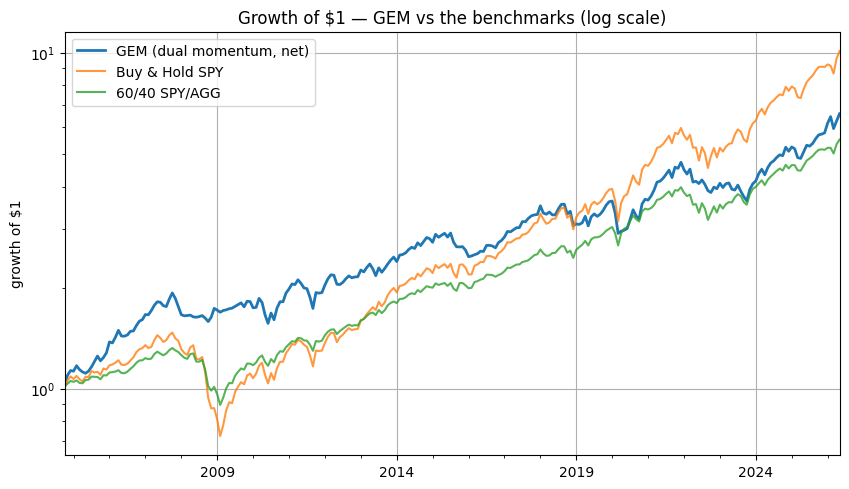

In [2]:
fig, ax = plt.subplots()
curve(gem).plot(ax=ax, label='GEM (dual momentum, net)', lw=2)
curve(spy).plot(ax=ax, label='Buy & Hold SPY', lw=1.5, alpha=.8)
curve(b40).plot(ax=ax, label='60/40 SPY/AGG', lw=1.5, alpha=.8)
ax.set_yscale('log'); ax.set_title('Growth of \$1 — GEM vs the benchmarks (log scale)')
ax.set_ylabel('growth of \$1'); ax.legend(); plt.show()

## 4 · The teardown — let's actually look

The headline table — Sharpe quoted both ways (raw, and after subtracting the T-bill return, which is the honest yardstick) — and the picture that explains it.

In [3]:
rows = {'GEM (net)': (gem,), 'Buy & Hold SPY': (spy,), '60/40 SPY/AGG': (b40,)}
tbl = pd.DataFrame({nm: {'Sharpe (raw)': st.summary(x)['sharpe'],
                         'Sharpe (excess of cash)': st.summary(x, rf=rf)['sharpe'],
                         'CAGR': st.summary(x)['cagr'],
                         'max drawdown': st.summary(x)['max_drawdown']}
                    for nm, (x,) in rows.items()}).T
display(tbl.style.format({'CAGR':'{:.1%}','max drawdown':'{:.1%}',
                          'Sharpe (raw)':'{:.2f}','Sharpe (excess of cash)':'{:.2f}'}))

,Sharpe (raw),Sharpe (excess of cash),CAGR,max drawdown
GEM (net),0.76,0.62,9.1%,-23.3%
Buy & Hold SPY,0.79,0.67,11.3%,-50.8%
60/40 SPY/AGG,0.87,0.68,8.2%,-32.3%


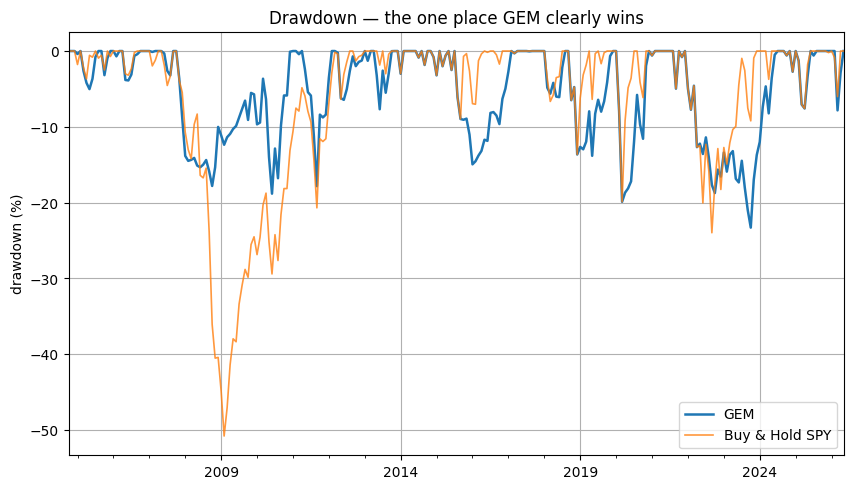

In [4]:
def underwater(s): c = curve(s); return c/c.cummax() - 1
fig, ax = plt.subplots()
(underwater(gem)*100).plot(ax=ax, label='GEM', lw=1.8)
(underwater(spy)*100).plot(ax=ax, label='Buy & Hold SPY', lw=1.2, alpha=.8)
ax.set_title('Drawdown — the one place GEM clearly wins'); ax.set_ylabel('drawdown (%)'); ax.legend(); plt.show()

**Read it plainly.** Same ballpark wealth as SPY, but the red 2008 canyon is half as deep — because GEM was sitting in bonds. That crash-cushion is real. It just isn't *extra return*: in both Sharpe conventions GEM trails SPY and the 60/40 line gets there without any timing at all.

## 5 · The verdict

**Signal: Weak** — the book makes money, but so does anything long stocks for 23 years; strip it down to the timing decision (the quants notebook regresses GEM on its own ingredients) and the added return is **t ≈ 0.5** — statistically nothing. **Tradability: Fragile** — its edge is one-dimensional crash protection that leans on a single 2008 and has faded since. **Beats the market?: Not supported** — it trails SPY and loses to 60/40, raw or excess. A sensible defensive rule wearing a paper-tiger headline.

## 6 · Could you actually trade it?

Yes — and that's the seductive part. It trades ~1.5×/year, costs are trivial (20 bp/switch barely dents it), and it's genuinely defensive. But "can you trade it" isn't the question; "does it beat the lazy alternative" is — and a 60/40 index portfolio wins on Sharpe with zero effort.

## 7 · Going further 🚪

The deep companion — [02_for_the_quants](02_for_the_quants.ipynb) — puts standard errors on every claim, runs the spanning regression that isolates the timing skill, shows the post-publication decay, and runs the portfolio test: does adding a GEM sleeve to a 60/40 help? (It trims drawdown; the Sharpe barely moves.) Contrast with [Study 31 Trade-Winds](../../31-trade-winds/), where a trend sleeve *does* lift a portfolio — that's the difference between real diversification and a paper tiger.